In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss

In [3]:
def plot_dist(mu, sd, color=None, shade=True, **kwargs):

    plt.plot(x, ss.norm(loc=mu, scale=sd).pdf(x), color=color, **kwargs, alpha=.8)

    if shade:
        plt.fill_between(x, 0.0, ss.norm(loc=mu, scale=sd).pdf(x), alpha=0.3, color=color)

    sns.despine()

In [4]:
def get_posterior(mu1, sd1, mu2, sd2):
    var1, var2 = sd1**2, sd2**2
    return mu1 + (var1/(var1+var2))*(mu2 - mu1), np.sqrt((var1*var2)/(var1+var2))

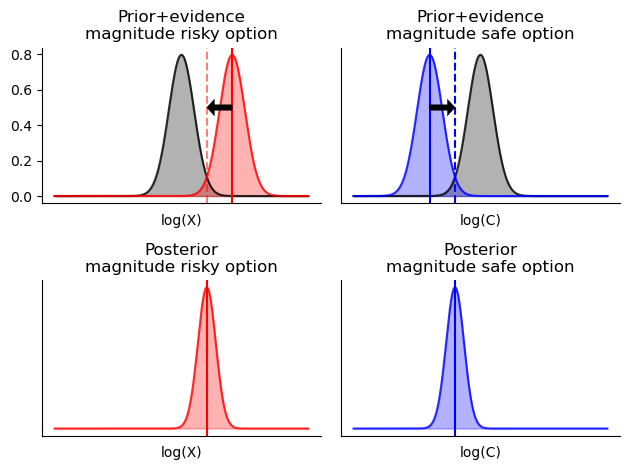

In [5]:
x = np.linspace(0, 10, 1000)

mu_prior, std_prior = 5., .5
mu_evidence_safe, std_evidence_safe = 3.0, .5
# mu_evidence_risky, std_evidence_risky = 7.0, .5
mu_evidence_risky, std_evidence_risky = 7.0, .5
mu_posterior_risky, std_posterior_risky = get_posterior(mu_evidence_risky, std_evidence_risky, mu_prior, std_prior)
mu_posterior_safe, std_posterior_safe = get_posterior(mu_evidence_safe, std_evidence_safe, mu_prior, std_prior)

ax = plt.subplot(221)
plt.title('Prior+evidence\nmagnitude risky option')
plot_dist(mu_prior, std_prior, color='black', label='Prior')
plot_dist(mu_evidence_risky, std_evidence_risky, color='red', label='Evidence risky option')
ax.annotate('', xytext=(mu_evidence_risky, .5), xy=(mu_posterior_risky, 0.5), arrowprops={"color":"black", "linewidth":.25, "headlength":5.5})
plt.axvline(mu_evidence_risky, c='red', ls='-')
plt.axvline(mu_posterior_risky, c='red', ls='--', alpha=.5)
plt.xlabel('log(X)')
plt.xticks([])

ax = plt.subplot(222)
plt.title('Prior+evidence\nmagnitude safe option')
plot_dist(mu_prior, std_prior, color='black', label='Prior')
plot_dist(mu_evidence_safe, std_evidence_safe, color='blue', label='Evidence safe option')
ax.annotate('', xytext=(mu_evidence_safe, .5), xy=(mu_posterior_safe, 0.5), arrowprops={"color":"black", "linewidth":.25, "headlength":5.5})
plt.axvline(mu_evidence_safe, c='blue', ls='-')
plt.axvline(mu_posterior_safe, c='blue', ls='--')
plt.xlabel('log(C)')
plt.yticks([])
plt.xticks([])

plt.subplot(223)
plt.title('Posterior\nmagnitude risky option')
plot_dist(mu_posterior_risky, std_posterior_risky, color='red', label='Evidence risky option')
plt.axvline(mu_posterior_risky, c='red', ls='-')
plt.xlabel('log(X)')
plt.yticks([])
plt.xticks([])

ax = plt.subplot(224)
plt.title('Posterior\nmagnitude safe option')
plot_dist(mu_posterior_safe, std_posterior_safe, color='blue', label='Evidence risky option')
plt.axvline(mu_posterior_safe, c='blue', ls='-')
plt.xlabel('log(C)')
plt.yticks([])
plt.xticks([])

plt.tight_layout()

In [6]:
def plot_dist(x, mu, sd, color=None, shade=True, norm=True, **kwargs):

    y = np.linspace(2, 8, 1000)
    p = ss.norm(loc=mu, scale=sd).pdf(y)
    if norm:
        p /= p.max()

    plt.plot(x + p, y, color=color, **kwargs, alpha=1.0)

    # plt.plot(x, ss.norm(loc=mu, scale=sd).pdf(x), color=color, **kwargs, alpha=.8)

    if shade:
        plt.fill_betweenx(y, x, x+p, alpha=0.3, color=color)

    # sns.despine()

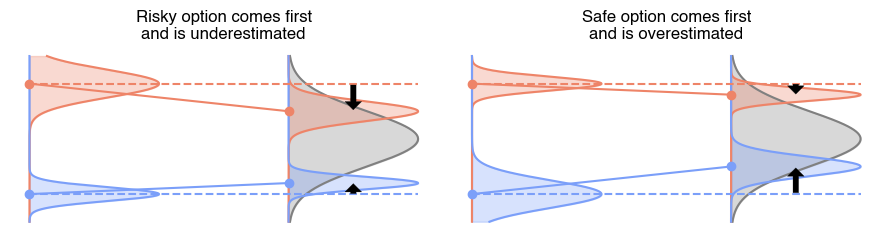

In [7]:
palette = sns.color_palette('coolwarm', 4)[::-1]

plt.subplot(121)
mu_evidence_risky, std_evidence_risky = 7.0, .5
mu_evidence_safe, std_evidence_safe = 3.0, .25
mu_prior, std_prior = 5.0, .5
mu_posterior_risky, std_posterior_risky = get_posterior(mu_evidence_risky, std_evidence_risky, mu_prior, std_prior)
mu_posterior_safe, std_posterior_safe = get_posterior(mu_evidence_safe, std_evidence_safe, mu_prior, std_prior)


plot_dist(2.0, 7.0, .5, shade=True, color=palette[0])
plot_dist(2.0, 3.0, .25, shade=True, color=palette[3])
plot_dist(4.0, 5.0, 1.0, shade=True, color='gray')
plot_dist(4.0, mu_posterior_risky, std_posterior_risky, shade=True, color=palette[0])
plot_dist(4.0, mu_posterior_safe, std_posterior_safe, shade=True, color=palette[3])

plt.plot([2.0, 5.0], [mu_evidence_risky, mu_evidence_risky], c=palette[0], ls='--')
plt.plot([2.0, 5.0], [mu_evidence_safe, mu_evidence_safe], c=palette[3], ls='--')

plt.plot([2., 4.], [mu_evidence_risky, mu_posterior_risky], c=palette[0], marker='o')
plt.plot([2., 4.], [mu_evidence_safe, mu_posterior_safe], c=palette[3], marker='o')

plt.axis('off')
plt.title('Risky option comes first\nand is underestimated', fontfamily='helvetica', style='italic')

plt.annotate('', xytext=(4.5, mu_evidence_safe), xy=(4.5, mu_posterior_safe), arrowprops={"color":'k', "linewidth":.2, 'shrink':0.05, 'headlength':6})
plt.annotate('', xytext=(4.5, mu_evidence_risky), xy=(4.5, mu_posterior_risky), arrowprops={"color":'k', "linewidth":.2, 'shrink':0.05, 'headlength':6})

plt.gcf().set_size_inches(15, 4)

plt.annotate('Likelihood', (2.2, 0.5), ha='left')
plt.annotate('Posterior', (4.2, 0.5), ha='left')

plt.subplot(122)
mu_evidence_risky, std_evidence_risky = 7.0, .25
mu_evidence_safe, std_evidence_safe = 3.0, .5
mu_prior, std_prior = 5.0, .5
mu_posterior_risky, std_posterior_risky = get_posterior(mu_evidence_risky, std_evidence_risky, mu_prior, std_prior)
mu_posterior_safe, std_posterior_safe = get_posterior(mu_evidence_safe, std_evidence_safe, mu_prior, std_prior)


plot_dist(2.0, mu_evidence_risky, std_evidence_risky, shade=True, color=palette[0])
plot_dist(2.0, mu_evidence_safe, std_evidence_safe, shade=True, color=palette[3])
plot_dist(4.0, 5.0, 1.0, shade=True, color='gray')
plot_dist(4.0, mu_posterior_risky, std_posterior_risky, shade=True, color=palette[0])
plot_dist(4.0, mu_posterior_safe, std_posterior_safe, shade=True, color=palette[3])
plt.plot([2.0, 5.0], [mu_evidence_risky, mu_evidence_risky], c=palette[0], ls='--')
plt.plot([2.0, 5.0], [mu_evidence_safe, mu_evidence_safe], c=palette[3], ls='--')

plt.plot([2., 4.], [mu_evidence_risky, mu_posterior_risky], c=palette[0], marker='o')
plt.plot([2., 4.], [mu_evidence_safe, mu_posterior_safe], c=palette[3], marker='o')

plt.axis('off')
plt.title('Safe option comes first\nand is overestimated', fontfamily='helvetica')
plt.annotate('Likelihood', (2.2, 0.15), ha='left')
plt.annotate('Posterior', (4.2, 0.15), ha='left')

plt.annotate('', xytext=(4.5, mu_evidence_safe), xy=(4.5, mu_posterior_safe), arrowprops={"color":'k', "linewidth":.2, 'shrink':0.05, 'headlength':6})
plt.annotate('', xytext=(4.5, mu_evidence_risky), xy=(4.5, mu_posterior_risky), arrowprops={"color":'k', "linewidth":.2, 'shrink':0.05, 'headlength':6})

plt.gcf().set_size_inches(9, 2.5)
plt.tight_layout()

plt.show()
#plt.savefig('/data/ds-risk/derivatives/figures/over_underestimation.pdf')

In [8]:
x = np.linspace(1.0, 9., 1000)
def plot_dist(mu, sd, y=0.0, color=None, shade=True, **kwargs):

    p = ss.norm(loc=mu, scale=sd).pdf(x)
    p /= p.max() / .65

    plt.plot(-y+x, y+p, color=color, **kwargs, alpha=.8)

    if shade:
        plt.fill_between(-y+x, y, y+p, alpha=0.3, color=color)

    sns.despine()

In [9]:
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.25, palette='tab10')

evi risky mu: 1096.63, EV = 603.15
evi safe mu: 20.09


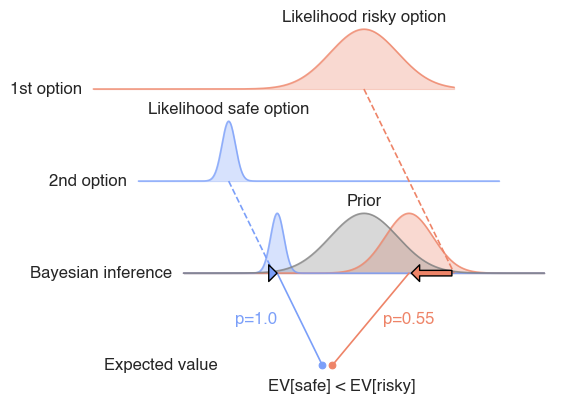

In [41]:
mu_evidence_risky, std_evidence_risky = 7., .75
mu_evidence_safe, std_evidence_safe = 3.0, .15
mu_prior, std_prior = (mu_evidence_risky+mu_evidence_safe)/2, .75
mu_posterior_risky, std_posterior_risky = get_posterior(mu_evidence_risky, std_evidence_risky, mu_prior, std_prior)
mu_posterior_safe, std_posterior_safe = get_posterior(mu_evidence_safe, std_evidence_safe, mu_prior, std_prior)

palette = sns.color_palette('coolwarm', 4)[::-1]

plot_dist(mu_evidence_risky, std_evidence_risky, color=palette[0]) # y=0.0 by default = height !

plot_dist(mu_evidence_safe, std_evidence_safe, -1.0, color=palette[3])

plot_dist(mu_posterior_risky, std_posterior_risky, -2.0, color=palette[0])
plot_dist(mu_posterior_safe, std_posterior_safe, -2.0, color=palette[3])
plt.plot([mu_evidence_risky, mu_evidence_risky+2], [0.0, -2.], ls='--', c=palette[0])
plot_dist(mu_prior, std_prior, -2.0, color='gray')

plt.plot([mu_evidence_safe+1, mu_evidence_safe+2], [-1.0, -2.], ls='--', c=palette[3])

plt.annotate('', xytext=(2+mu_evidence_safe, -2), xy=(2+mu_posterior_safe, -2), arrowprops={"facecolor":palette[3], 'edgecolor':'k', "linewidth":1., 'shrink':0.05, 'headlength':6})
plt.annotate('', xytext=(2+mu_evidence_risky, -2), xy=(2+mu_posterior_risky, -2), arrowprops={"facecolor":palette[0], "linewidth":1., 'edgecolor':'k', 'shrink':0.05, 'headlength':6})

# draw the 4 lines 
for ix in range(4):
    plt.plot([ix+1, ix+9], [-ix, -ix], c='gray', ls='-')


plt.gca().annotate('1st option', (.75, 0.0), ha='right', va='center')
plt.gca().annotate('Likelihood risky option', (mu_evidence_risky, .7), ha='center', va='bottom')

plt.gca().annotate('2nd option', (1.75, -1.0), ha='right', va='center')
plt.gca().annotate('Likelihood safe option', (1+mu_evidence_safe, -.3), ha='center', va='bottom')

plt.gca().annotate('Prior', (2+mu_prior, -1.3), ha='center', va='bottom')
# plt.gca().annotate('Safe posterior', (mu_posterior_safe+1.5, -1.5), ha='right', va='bottom')
# plt.gca().annotate('Risky posterior', (mu_posterior_risky+2.75, -1.5), ha='left', va='bottom')

plt.gca().annotate('Bayesian inference', (2.75, -2.0), ha='right', va='center')
plt.gca().annotate('Expected value', (3.75, -3.0), ha='right', va='center')

plt.gca().annotate('p=0.55', (8., -2.5),  ha='center', va='center', color=palette[0])
plt.gca().annotate('p=1.0', (4.6, -2.5),  ha='center', va='center', color=palette[3])

plt.gca().annotate('EV[safe] < EV[risky]', (6.5, -3.15),  ha='center', va='top')

plt.scatter([3+mu_posterior_safe], [-3.], color=palette[3], zorder=10)
plt.scatter([3+mu_posterior_risky*.55], [-3.], color=palette[0], zorder=10)

plt.plot([mu_posterior_safe+2, mu_posterior_safe+3], [-2, -3], color=palette[3])
plt.plot([mu_posterior_risky+2, mu_posterior_risky*.55+3], [-2, -3], color=palette[0])


plt.axis('off')
#plt.savefig('/data/ds-risk/derivatives/figures/illustration_risky_first.pdf', bbox_inches='tight')
print(f'evi risky mu: {np.round(np.exp(mu_evidence_risky),2)}, EV = {np.round(0.55 * np.exp(mu_evidence_risky),2)}')
print(f'evi safe mu: {np.round(np.exp(mu_evidence_safe),2)}')

evi risky mu: 33.12, EV = 18.21
evi safe mu: 20.09


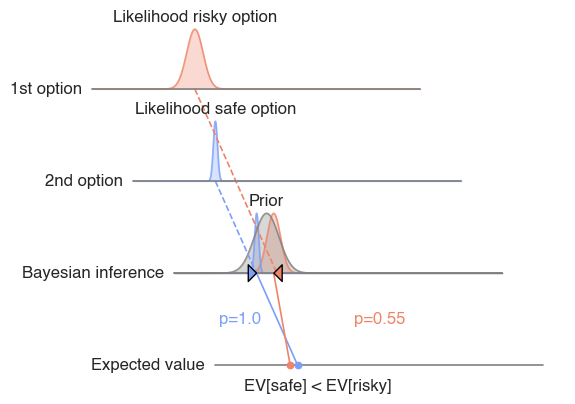

In [36]:
mu_evidence_risky, std_evidence_risky = 3.5, .2
mu_evidence_safe, std_evidence_safe = 3.0, .05
mu_prior, std_prior = (mu_evidence_risky+mu_evidence_safe)/2, .3
mu_posterior_risky, std_posterior_risky = get_posterior(mu_evidence_risky, std_evidence_risky, mu_prior, std_prior)
mu_posterior_safe, std_posterior_safe = get_posterior(mu_evidence_safe, std_evidence_safe, mu_prior, std_prior)

palette = sns.color_palette('coolwarm', 4)[::-1]

plot_dist(mu_evidence_risky, std_evidence_risky, color=palette[0])

plot_dist(mu_evidence_safe, std_evidence_safe, -1.0, color=palette[3])

plot_dist(mu_posterior_risky, std_posterior_risky, -2.0, color=palette[0])
plot_dist(mu_posterior_safe, std_posterior_safe, -2.0, color=palette[3])
plt.plot([mu_evidence_risky, mu_evidence_risky+2], [0.0, -2.], ls='--', c=palette[0])
plot_dist(mu_prior, std_prior, -2.0, color='gray')

plt.plot([mu_evidence_safe+1, mu_evidence_safe+2], [-1.0, -2.], ls='--', c=palette[3])

plt.annotate('', xytext=(2+mu_evidence_safe, -2), xy=(2+mu_posterior_safe, -2), arrowprops={"facecolor":palette[3], 'edgecolor':'k', "linewidth":1., 'shrink':0.05, 'headlength':6})
plt.annotate('', xytext=(2+mu_evidence_risky, -2), xy=(2+mu_posterior_risky, -2), arrowprops={"facecolor":palette[0], "linewidth":1., 'edgecolor':'k', 'shrink':0.05, 'headlength':6})


for ix in range(4):
    plt.plot([ix+1, ix+9], [-ix, -ix], c='gray', ls='-')


plt.gca().annotate('1st option', (.75, 0.0), ha='right', va='center')
plt.gca().annotate('Likelihood risky option', (mu_evidence_risky, .7), ha='center', va='bottom')

plt.gca().annotate('2nd option', (1.75, -1.0), ha='right', va='center')
plt.gca().annotate('Likelihood safe option', (1+mu_evidence_safe, -.3), ha='center', va='bottom')

plt.gca().annotate('Prior', (2+mu_prior, -1.3), ha='center', va='bottom')
# plt.gca().annotate('Safe posterior', (mu_posterior_safe+1.5, -1.5), ha='right', va='bottom')
# plt.gca().annotate('Risky posterior', (mu_posterior_risky+2.75, -1.5), ha='left', va='bottom')

plt.gca().annotate('Bayesian inference', (2.75, -2.0), ha='right', va='center')
plt.gca().annotate('Expected value', (3.75, -3.0), ha='right', va='center')

plt.gca().annotate('p=0.55', (8., -2.5),  ha='center', va='center', color=palette[0])
plt.gca().annotate('p=1.0', (4.6, -2.5),  ha='center', va='center', color=palette[3])

plt.gca().annotate('EV[safe] < EV[risky]', (6.5, -3.15),  ha='center', va='top')

plt.scatter([3+mu_posterior_safe], [-3.], color=palette[3], zorder=10)
plt.scatter([3+mu_posterior_risky+np.log(.55)], [-3.], color=palette[0], zorder=10)

plt.plot([mu_posterior_safe+2, mu_posterior_safe+3], [-2, -3], color=palette[3])
plt.plot([mu_posterior_risky+2, mu_posterior_risky+np.log(.55)+3], [-2, -3], color=palette[0])


plt.axis('off')
# plt.savefig('/data/ds-risk/derivatives/figures/illustration_risky_first.pdf', bbox_inches='tight')
print(f'evi risky mu: {np.round(np.exp(mu_evidence_risky),2)}, EV = {np.round(0.55 * np.exp(mu_evidence_risky),2)}')
print(f'evi safe mu: {np.round(np.exp(mu_evidence_safe),2)}')



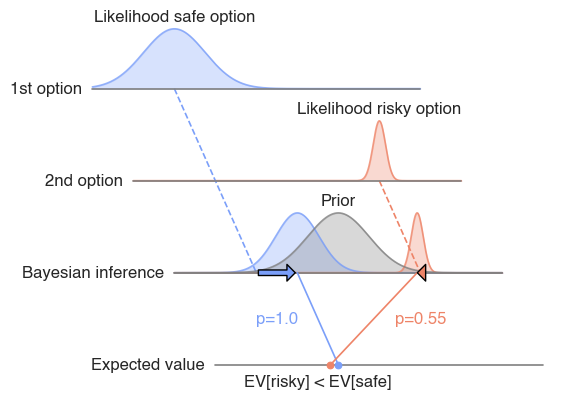

In [420]:
mu_evidence_risky, std_evidence_risky = 7., .15
mu_evidence_safe, std_evidence_safe = 3.0, .75
mu_prior, std_prior = (mu_evidence_risky+mu_evidence_safe)/2, .75
mu_posterior_risky, std_posterior_risky = get_posterior(mu_evidence_risky, std_evidence_risky, mu_prior, std_prior)
mu_posterior_safe, std_posterior_safe = get_posterior(mu_evidence_safe, std_evidence_safe, mu_prior, std_prior)

palette = sns.color_palette('coolwarm', 4)[::-1]

plot_dist(mu_evidence_safe, std_evidence_safe, color=palette[3])

plot_dist(mu_evidence_risky, std_evidence_risky, -1.0, color=palette[0])

plot_dist(mu_posterior_safe, std_posterior_safe, -2.0, color=palette[3])
plot_dist(mu_posterior_risky, std_posterior_risky, -2.0, color=palette[0])
plt.plot([mu_evidence_safe, mu_evidence_safe+2], [0.0, -2.], ls='--', c=palette[3])
plot_dist(mu_prior, std_prior, -2.0, color='gray')

plt.plot([mu_evidence_risky+1, mu_evidence_risky+2], [-1.0, -2.], ls='--', c=palette[0])

plt.annotate('', xytext=(2+mu_evidence_safe, -2), xy=(2+mu_posterior_safe, -2), arrowprops={"facecolor":palette[3], 'edgecolor':'k', "linewidth":1., 'shrink':0.05, 'headlength':6})
plt.annotate('', xytext=(2+mu_evidence_risky, -2), xy=(2+mu_posterior_risky, -2), arrowprops={"facecolor":palette[0], "linewidth":1., 'edgecolor':'k', 'shrink':0.05, 'headlength':6})


for ix in range(4):
    plt.plot([ix+1, ix+9], [-ix, -ix], c='gray', ls='-')


plt.gca().annotate('1st option', (.75, 0.0), ha='right', va='center')
plt.gca().annotate('Likelihood safe option', (mu_evidence_safe, .7), ha='center', va='bottom')

plt.gca().annotate('2nd option', (1.75, -1.0), ha='right', va='center')
plt.gca().annotate('Likelihood risky option', (1+mu_evidence_risky, -.3), ha='center', va='bottom')

plt.gca().annotate('Prior', (2+mu_prior, -1.3), ha='center', va='bottom')
# plt.gca().annotate('Safe posterior', (mu_posterior_safe+1.5, -1.5), ha='right', va='bottom')
# plt.gca().annotate('Risky posterior', (mu_posterior_risky+2.75, -1.5), ha='left', va='bottom')

plt.gca().annotate('Bayesian inference', (2.75, -2.0), ha='right', va='center')
plt.gca().annotate('Expected value', (3.75, -3.0), ha='right', va='center')

plt.gca().annotate('p=0.55', (9., -2.5),  ha='center', va='center', color=palette[0])
plt.gca().annotate('p=1.0', (5.5, -2.5),  ha='center', va='center', color=palette[3])

plt.gca().annotate('EV[risky] < EV[safe]', (6.5, -3.1),  ha='center', va='top')

plt.scatter([3+mu_posterior_safe], [-3.], color=palette[3], zorder=10)
plt.scatter([3+mu_posterior_risky*.55], [-3.], color=palette[0], zorder=10)

plt.plot([mu_posterior_safe+2, mu_posterior_safe+3], [-2, -3], color=palette[3])
plt.plot([mu_posterior_risky+2, mu_posterior_risky*.55+3], [-2, -3], color=palette[0])


plt.axis('off')
plt.savefig('/data/ds-risk/derivatives/figures/illustration_safe_first.pdf', bbox_inches='tight')

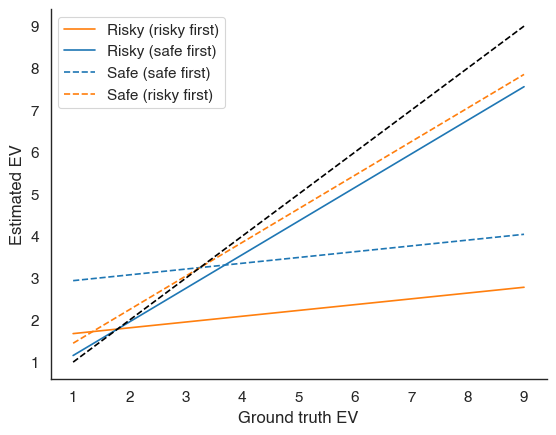

In [11]:
ev = np.linspace(1, 9, 100)
risky_options = ev/.55
safe_options = ev

std_first = .75
std_second = .15

std_prior_scale = 1.

e_ev_risky_first = np.array([get_posterior(ro, std_first, mu_prior, std_prior*std_prior_scale)[0] for ro in risky_options]) * .55
e_ev_risky_second = np.array([get_posterior(ro, std_second, mu_prior, std_prior*std_prior_scale)[0] for ro in risky_options]) * .55
e_ev_safe_first = np.array([get_posterior(so, std_first, mu_prior, std_prior*std_prior_scale)[0] for so in safe_options])
e_ev_safe_second = np.array([get_posterior(so, std_second, mu_prior, std_prior*std_prior_scale)[0] for so in safe_options])


plt.plot(ev, e_ev_risky_first, label='Risky (risky first)', color=sns.color_palette()[1])
plt.plot(ev, e_ev_risky_second, label='Risky (safe first)', color=sns.color_palette()[0])

plt.plot(ev, e_ev_safe_first, color=sns.color_palette()[0], ls='--', label='Safe (safe first)')
plt.plot(ev, e_ev_safe_second, color=sns.color_palette()[1], ls='--', label='Safe (risky first)')

plt.plot([1, 9], [1, 9], c='k', ls='--')
plt.legend()

plt.xlabel('Ground truth EV')
plt.ylabel('Estimated EV')
# risky_ev_second = [get_posterior(ro, .15, mu_prior, std_prior)[0] for ro in risky_options]

# plt.plot(risky_options, risky_ev_first)
# plt.plot(risky_options, risky_ev_second)
sns.despine()

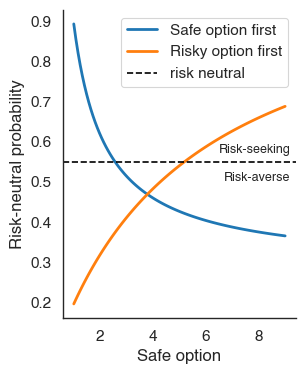

In [437]:
plt.plot(safe_options,  e_ev_risky_first/ e_ev_safe_second*.55, lw=2, label='Safe option first')
plt.plot(safe_options, e_ev_risky_second / e_ev_safe_first*.55, lw=2, label='Risky option first')
plt.axhline(.55, c='k', ls='--', label='risk neutral')

sns.despine()
plt.ylabel('Risk-neutral probability')
plt.xlabel('Safe option')
plt.annotate('Risk-seeking', (9.2, .565), ha='right', va='bottom', fontsize=9.)
plt.annotate('Risk-averse', (9.2, .525), ha='right', va='top', fontsize=9.)
plt.legend()


plt.gcf().set_size_inches(3, 4)
plt.savefig('/data/ds-risk/derivatives/figures/illustration_safe_vs_rnp.pdf', bbox_inches='tight')

In [31]:
# my version,
# without moving leftwards when moving downwards, different priors possible
# 2 subversions:
    # 1. numerosities as before (unrealistic but nicely visualize the concept) + priors plotted together with evidence
    # 2. numerosities more realistic + priors plotted together with posteriors + risky_first&common_prior changable

base_n = [5,7,10,14,20,27]

x = np.linspace(1.0, 9., 1000)

def plot_dist(mu, sd, y=0.0, color=None, shade=True, **kwargs):

    p = ss.norm(loc=mu, scale=sd).pdf(x)
    p /= p.max() / .65

    plt.plot(x, y+p, color=color, **kwargs, alpha=.8)

    if shade:
        plt.fill_between(x, y, y+p, alpha=0.3, color=color)

    sns.despine()

In [36]:
sns.color_palette('coolwarm')

[(0.4044212904941176, 0.5346434904470588, 0.9320019126352941),
 (0.603162067917647, 0.7315274773529412, 0.9995652785372549),
 (0.7867207013568628, 0.8448072103686275, 0.9398103849490196),
 (0.9306685963333333, 0.818876999654902, 0.7591463906980392),
 (0.9673165156666667, 0.6574708288078431, 0.5381601507294118),
 (0.8846434386941177, 0.41001709788235297, 0.32250654924705885)]

evi risky mu: 1096.63, EV = 603.15
evi safe mu: 20.09


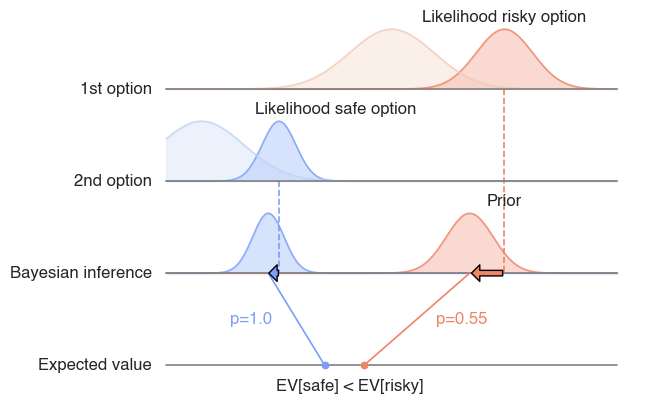

In [72]:
# 1. priors plotted together with evidence
# 

mu_evidence_risky, std_evidence_risky = 7., .5
mu_evidence_safe, std_evidence_safe = 3.0, .3
mu_prior, std_prior = (mu_evidence_risky+mu_evidence_safe)/2, .75

mu_prior_safe, std_prior_safe = np.log(np.mean(base_n))-1, .75
mu_prior_risky, std_prior_risky = 5, .75 # np.log(np.mean(base_n))* 1.55


mu_posterior_risky, std_posterior_risky = get_posterior(mu_evidence_risky, std_evidence_risky, mu_prior_risky, std_prior_risky)
mu_posterior_safe, std_posterior_safe = get_posterior(mu_evidence_safe, std_evidence_safe, mu_prior_safe, std_prior_safe)

palette = sns.color_palette('coolwarm', 4)[::-1]

# first risky
plot_dist(mu_evidence_risky, std_evidence_risky, color=palette[0]) # y=0.0 by default = height !
plot_dist(mu_prior_risky, std_prior_risky,  color=palette[1])

#second safe
plot_dist(mu_evidence_safe, std_evidence_safe,  -1.0, color=palette[3])
plot_dist(mu_prior_safe, std_prior_safe, -1.0, color=palette[2])


plot_dist(mu_posterior_risky, std_posterior_risky, -2.0, color=palette[0])
plot_dist(mu_posterior_safe, std_posterior_safe, -2.0, color=palette[3])
plt.plot([mu_evidence_risky, mu_evidence_risky], [0.0, -2.], ls='--', c=palette[0])
plt.plot([mu_evidence_safe, mu_evidence_safe], [-1, -2.], ls='--', c=palette[3])

# arrows
plt.annotate('', xytext=(mu_evidence_safe, -2), xy=(mu_posterior_safe, -2), arrowprops={"facecolor":palette[3], 'edgecolor':'k', "linewidth":1., 'shrink':0.05, 'headlength':6})
plt.annotate('', xytext=(mu_evidence_risky, -2), xy=(mu_posterior_risky, -2), arrowprops={"facecolor":palette[0], "linewidth":1., 'edgecolor':'k', 'shrink':0.05, 'headlength':6})

# draw the 4 lines 
for ix in range(4):
    plt.plot([1, 9], [-ix, -ix], c='gray', ls='-')


plt.gca().annotate('1st option', (.75, 0.0), ha='right', va='center')
plt.gca().annotate('Likelihood risky option', (mu_evidence_risky, .7), ha='center', va='bottom')

plt.gca().annotate('2nd option', (0.75, -1.0), ha='right', va='center')
plt.gca().annotate('Likelihood safe option', (1+mu_evidence_safe, -.3), ha='center', va='bottom')

plt.gca().annotate('Prior', (2+mu_prior, -1.3), ha='center', va='bottom')
# plt.gca().annotate('Safe posterior', (mu_posterior_safe+1.5, -1.5), ha='right', va='bottom')
# plt.gca().annotate('Risky posterior', (mu_posterior_risky+2.75, -1.5), ha='left', va='bottom')

plt.gca().annotate('Bayesian inference', (0.75, -2.0), ha='right', va='center')
plt.gca().annotate('Expected value', (0.75, -3.0), ha='right', va='center')
plt.gca().annotate('p=0.55', (6.25, -2.5),  ha='center', va='center', color=palette[0])
plt.gca().annotate('p=1.0', (2.5, -2.5),  ha='center', va='center', color=palette[3])
plt.gca().annotate('EV[safe] < EV[risky]', (4.25, -3.15),  ha='center', va='top')

# EV
plt.scatter([1+mu_posterior_safe], [-3.], color=palette[3], zorder=10) # dots
plt.scatter([1+mu_posterior_risky*.55], [-3.], color=palette[0], zorder=10)
plt.plot([mu_posterior_safe, mu_posterior_safe+1], [-2, -3], color=palette[3]) # lines connecting with aboove
plt.plot([mu_posterior_risky, mu_posterior_risky*.55+1], [-2, -3], color=palette[0])


plt.axis('off')
#plt.savefig('/data/ds-risk/derivatives/figures/illustration_risky_first.pdf', bbox_inches='tight')
print(f'evi risky mu: {np.round(np.exp(mu_evidence_risky),2)}, EV = {np.round(0.55 * np.exp(mu_evidence_risky),2)}')
print(f'evi safe mu: {np.round(np.exp(mu_evidence_safe),2)}')

Text(7, -2.65, 'post safe mu: 6.84')

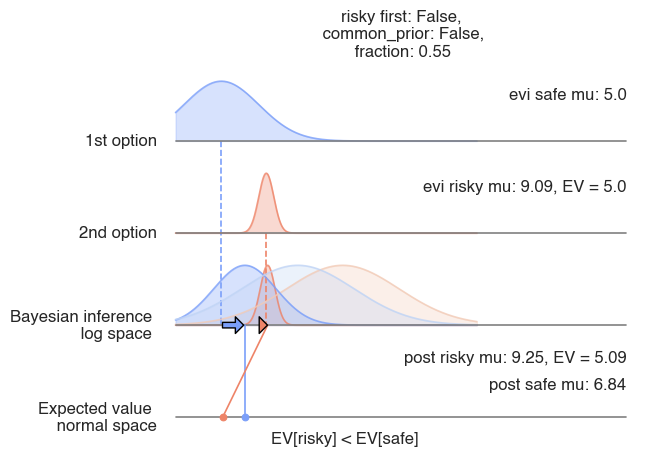

In [240]:
# 2. illustration with numerosities closer to actual experiment (but less clear visualization of the concept)
# set risky_first & common_prior, 
# set base (where are we on number line) & frac (big,small difference)

risky_first = False
common_prior = False 
base = base_n[0] # decide on a base number, where on number line we are
frac = fractions[3] # 3 = 0.55, neutral

x = np.linspace(1.0, np.log(150), 1000) # about 90 is the max amount that they will be paid

base_n = [5,7,10,14,20,27]
fractions = np.linspace(0.25, 0.85, 7, True)

#priors
mu_prior_safe, std_prior_safe = np.log(np.mean(base_n)), .75
mu_prior_risky, std_prior_risky = np.log(np.mean(np.array(base_n)/0.55)), .75 # np.log(np.mean(base_n))* 1.55

# evidence_std
sd_ev_1st = 0.5
sd_ev_2nd = 0.1
std_evidence_risky = sd_ev_1st if risky_first else sd_ev_2nd
std_evidence_safe = sd_ev_1st if risky_first == False else sd_ev_2nd


mu_evidence_risky = np.log(base/frac)
mu_evidence_safe = np.log(base)

if common_prior:
    mu_prior, std_prior = 3.5 , .75# (mu_evidence_risky+mu_evidence_safe)/2, .75
    mu_prior_risky = mu_prior
    mu_prior_safe = mu_prior

#posteriors
mu_posterior_risky, std_posterior_risky = get_posterior(mu_evidence_risky, std_evidence_risky, mu_prior_risky, std_prior_risky)
mu_posterior_safe, std_posterior_safe = get_posterior(mu_evidence_safe, std_evidence_safe, mu_prior_safe, std_prior_safe)


#first
mu_evidence_first = mu_evidence_risky if risky_first else mu_evidence_safe
col_first = palette[0] if risky_first else palette[3]
plot_dist(mu_evidence_first, sd_ev_1st, color=col_first) # y=0.0 by default = height !
plt.plot([mu_evidence_first, mu_evidence_first], [0.0, -2.], ls='--', c=col_first) #straight lines down

#second 
mu_evidence_second = mu_evidence_safe if risky_first else mu_evidence_risky
col_sec = palette[3] if risky_first else palette[0]
plot_dist(mu_evidence_second, sd_ev_2nd,  -1.0, color=col_sec)
plt.plot([mu_evidence_second, mu_evidence_second], [-1, -2.], ls='--', c=col_sec)

# bayesian inference
plot_dist(mu_posterior_risky, std_posterior_risky, -2.0, color=palette[0]) # risky
plot_dist(mu_prior_risky, std_prior_risky, -2.0, color=palette[1])
plot_dist(mu_posterior_safe, std_posterior_safe, -2.0, color=palette[3]) # safe
plot_dist(mu_prior_safe, std_prior_safe, -2.0, color=palette[2])


# arrows
plt.annotate('', xytext=(mu_evidence_safe, -2), xy=(mu_posterior_safe, -2), arrowprops={"facecolor":palette[3], 'edgecolor':'k', "linewidth":1., 'shrink':0.05, 'headlength':6})
plt.annotate('', xytext=(mu_evidence_risky, -2), xy=(mu_posterior_risky, -2), arrowprops={"facecolor":palette[0], "linewidth":1., 'edgecolor':'k', 'shrink':0.05, 'headlength':6})

# draw the 4 lines 
for ix in range(4):
    plt.plot([1,7], [-ix, -ix], c='gray', ls='-') # np.log(90)

plt.gca().annotate('1st option', (.75, 0.0), ha='right', va='center')
plt.gca().annotate('2nd option', (0.75, -1.0), ha='right', va='center')

plt.gca().annotate('Bayesian inference \n log space ', (0.75, -2.0), ha='right', va='center')
plt.gca().annotate('Expected value \n normal space', (0.75, -3.0), ha='right', va='center')


post_ev_norm_safe = np.exp(mu_posterior_safe) # expected value
post_ev_norm_risky = 0.55 * np.exp(mu_posterior_risky)

if  post_ev_norm_safe > post_ev_norm_risky: #mu_posterior_safe >  mu_posterior_risky*.55:
    plt.gca().annotate('EV[risky] < EV[safe]', (3.25, -3.15),  ha='center', va='top')
else:
    plt.gca().annotate('EV[safe] < EV[risky]', (3.25, -3.15),  ha='center', va='top')

# EV
post_ev_norm_safe = mu_posterior_safe #post_ev_norm_safe * (7/100) + 1
post_ev_norm_risky = mu_posterior_risky + np.log(0.55) #post_ev_norm_risky * (7/100) + 1

plt.scatter([post_ev_norm_safe], [-3.], color=palette[3], zorder=10) # dots
plt.scatter([post_ev_norm_risky], [-3.], color=palette[0], zorder=10)
plt.plot([mu_posterior_safe, post_ev_norm_safe], [-2, -3], color=palette[3]) # lines connecting with aboove
plt.plot([mu_posterior_risky, post_ev_norm_risky], [-2, -3], color=palette[0])

plt.title(f'risky first: {risky_first},\n common_prior: {common_prior},\n fraction: {frac}')
plt.axis('off')
#plt.savefig('/data/ds-risk/derivatives/figures/illustration_risky_first.pdf', bbox_inches='tight')

txt_risky_ev = f'evi risky mu: {np.round(np.exp(mu_evidence_risky),2)}, EV = {np.round(0.55 * np.exp(mu_evidence_risky),2)}'
txt_safe_ev = f'evi safe mu: {np.round(np.exp(mu_evidence_safe),2)}'
txt1 = txt_risky_ev if risky_first else txt_safe_ev
txt2 = txt_safe_ev if risky_first else txt_risky_ev
plt.gca().annotate(txt1, (7,0.5),ha='right', va='center')
plt.gca().annotate(txt2, (7,-0.5),ha='right', va='center')

txt_risky_post = f'post risky mu: {np.round(np.exp(mu_posterior_risky),2)}, EV = {np.round(0.55 * np.exp(mu_posterior_risky),2)}'
txt_safe_post= f'post safe mu: {np.round(np.exp(mu_posterior_safe),2)}'

plt.gca().annotate(txt_risky_post, (7,-2.35),ha='right', va='center')
plt.gca().annotate(txt_safe_post, (7,-2.65),ha='right', va='center')



In [209]:
post_ev_norm_safe = mu_posterior_safe #post_ev_norm_safe * (7/100) + 1
post_ev_norm_risky = 0.55 * mu_posterior_risky #post_ev_norm_risky * (7/100) + 1

post_ev_norm_safe = np.exp(mu_posterior_safe) # expected value
post_ev_norm_risky = 0.55 * np.exp(mu_posterior_risky)



2.135095899205489

In [230]:
mu_posterior_risky + np.log(0.55)

3.284155543254359

In [225]:
np.log(np.exp(mu_posterior_risky)* 0.55)

3.284155543254359

In [224]:
np.exp(mu_posterior_risky)* 0.55

26.686439253417223

In [211]:
mu_posterior_safe

3.090065872947164

In [218]:
np.exp(mu_posterior_safe)

21.97852571834275

In [143]:
# the original task (make_trial_design.py, utils.py)

import pandas as pd
from itertools import product

fractions = np.linspace(1.2, 2.2, 6, True) # fractions = np.exp(np.linspace(np.log(x_lower), np.log(x_upper), 6, True)) # x_lower, x_upper = fit_psychometric_curve(log_file, plot=True)

df = pd.DataFrame(product(base_n, fractions), columns=[
                    'base number', 'fraction'])
df['risky_n'] = (df['fraction'] * df['base number']).astype(int)    
df.head()

,base number,fraction,risky_n
0,5,1.2,6
1,5,1.4,7
2,5,1.6,8
3,5,1.8,9
4,5,2.0,10


In [179]:
mu_evidence_risky+mu_evidence_safe/2

5.541592299762113